In [1]:
from datasets import load_from_disk

ds = load_from_disk("../data/train_pairs")
ds = ds.select_columns(['anchor', 'intent'])

In [2]:
from sentence_transformers import SentenceTransformer
from peft import PeftModel

base_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cuda")
finetuned_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cuda")
peft = PeftModel.from_pretrained(finetuned_model[0].auto_model, "../training/model")
merged = peft.merge_and_unload()
finetuned_model[0].auto_model = merged

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
import os

os.makedirs("../training/centroids/base", exist_ok=True)
os.makedirs("../training/centroids/finetuned", exist_ok=True)

In [4]:
import numpy as np

for intent in ds.unique("intent"):
    print(f"Computing: {intent}")

    intent_texts = ds.filter(lambda x: x["intent"] == intent)["anchor"]

    base_centroid = base_model.encode(intent_texts, convert_to_tensor=True, normalize_embeddings=True).mean(dim=0)
    base_centroid = base_centroid / base_centroid.norm()
    np.save(f"../training/centroids/base/{intent}_centroid.npy", base_centroid.cpu().numpy())

    ft_centroid = finetuned_model.encode(intent_texts, convert_to_tensor=True, normalize_embeddings=True).mean(dim=0)
    ft_centroid = ft_centroid / ft_centroid.norm()
    np.save(f"../training/centroids/finetuned/{intent}_centroid.npy", ft_centroid.cpu().numpy())

    print(f"  Done: {intent}")

Computing: card_arrival
  Done: card_arrival
Computing: card_linking
  Done: card_linking
Computing: exchange_rate
  Done: exchange_rate
Computing: card_payment_wrong_exchange_rate
  Done: card_payment_wrong_exchange_rate
Computing: extra_charge_on_statement
  Done: extra_charge_on_statement
Computing: pending_cash_withdrawal
  Done: pending_cash_withdrawal
Computing: fiat_currency_support
  Done: fiat_currency_support
Computing: card_delivery_estimate
  Done: card_delivery_estimate
Computing: automatic_top_up
  Done: automatic_top_up
Computing: card_not_working
  Done: card_not_working
Computing: exchange_via_app
  Done: exchange_via_app
Computing: lost_or_stolen_card
  Done: lost_or_stolen_card
Computing: age_limit
  Done: age_limit
Computing: pin_blocked
  Done: pin_blocked
Computing: contactless_not_working
  Done: contactless_not_working
Computing: top_up_by_bank_transfer_charge
  Done: top_up_by_bank_transfer_charge
Computing: pending_top_up
  Done: pending_top_up
Computing: canc

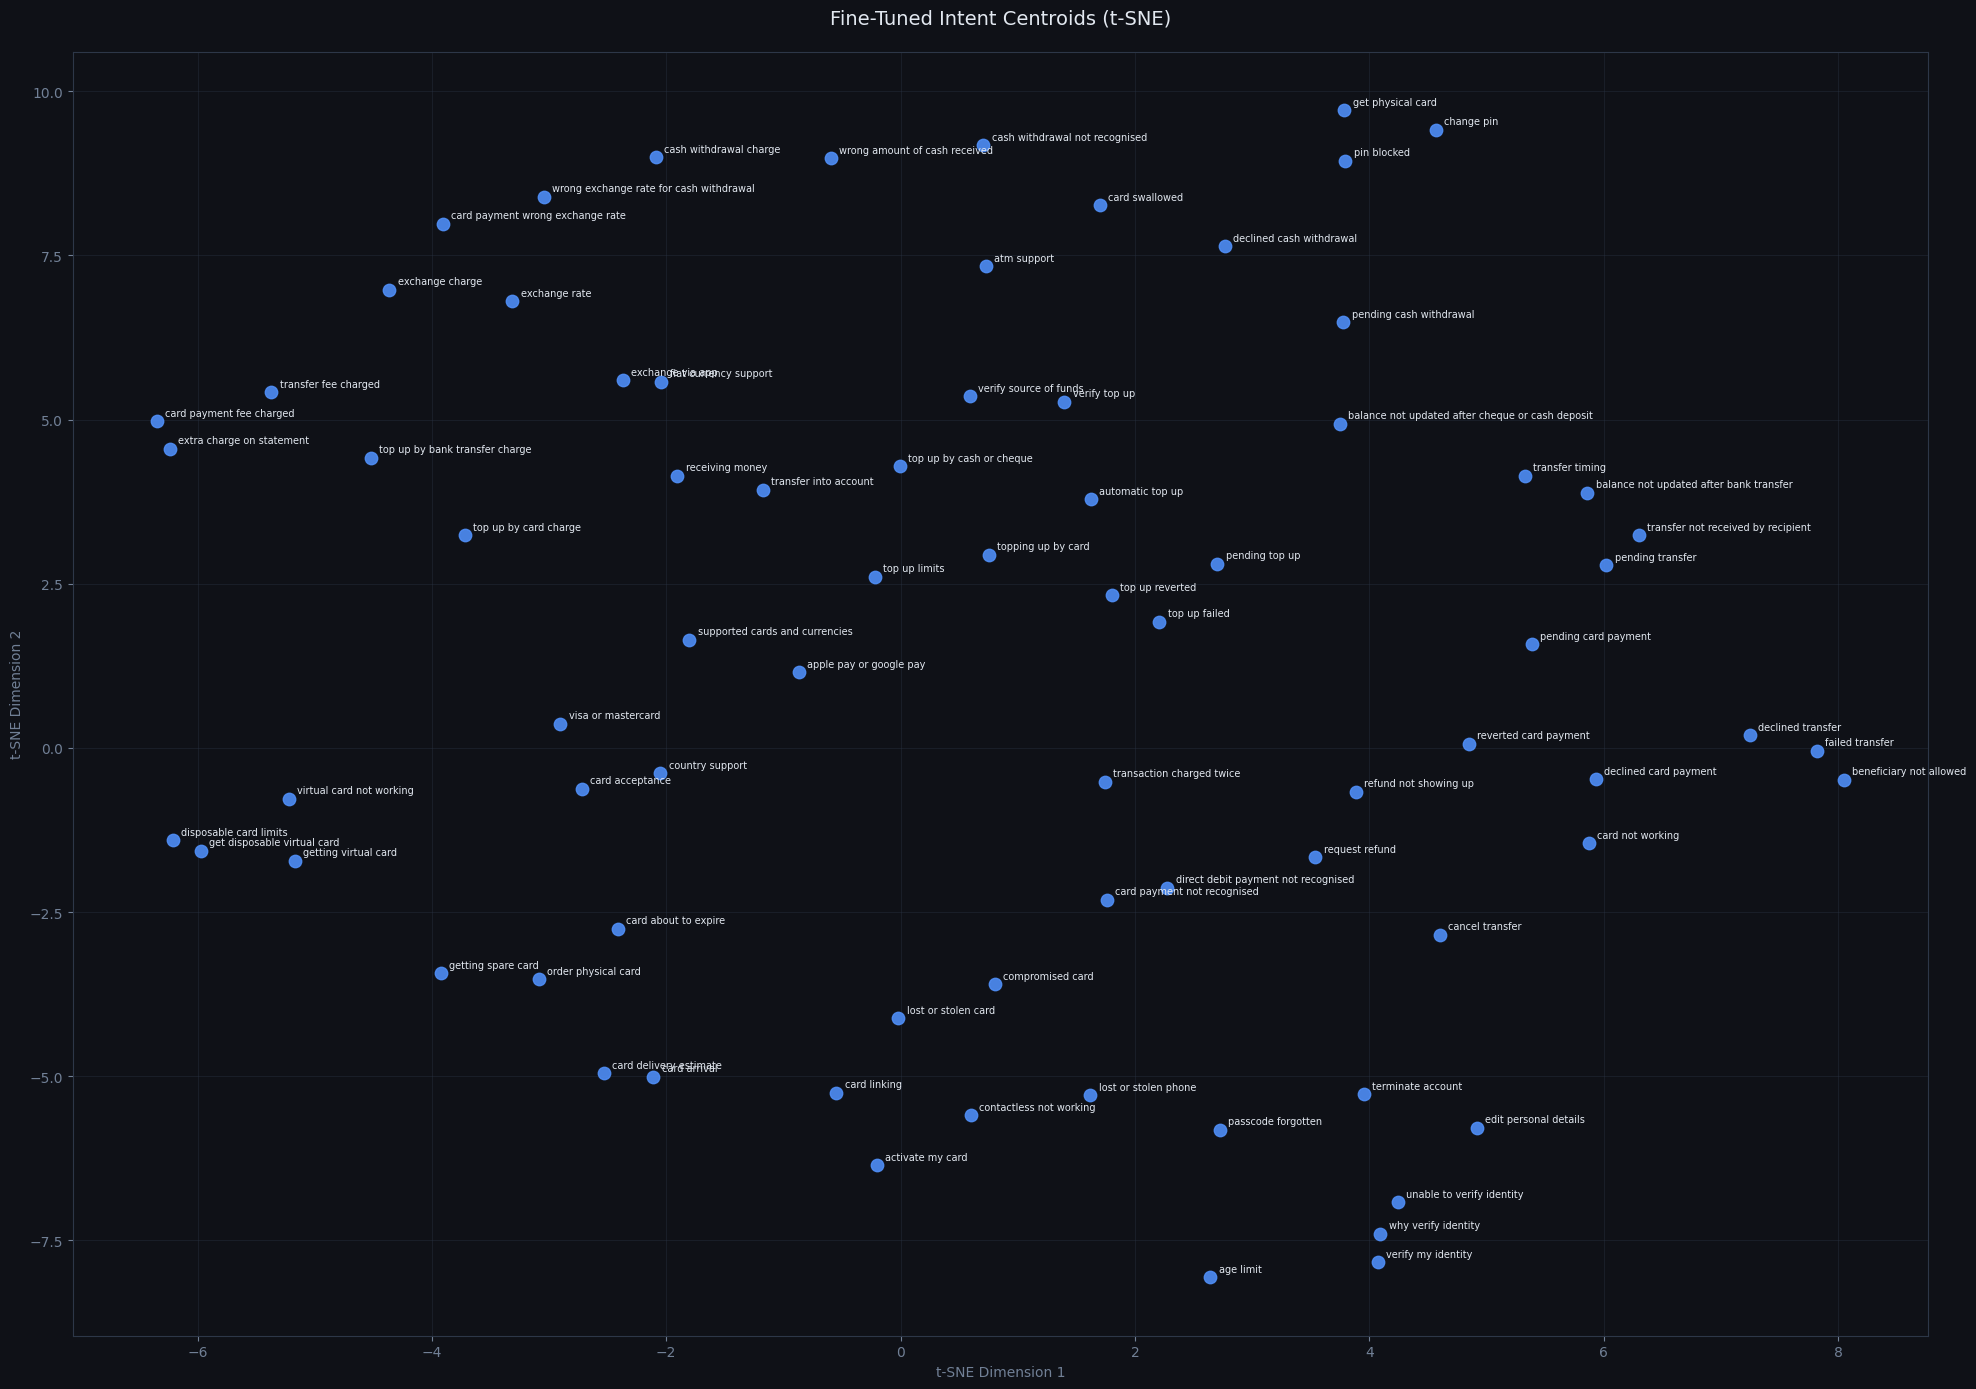

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os

intent_names = [
    f.replace("_centroid.npy", "") for f in os.listdir("../training/centroids/finetuned")
]

ft_matrix = np.stack([
    np.load(f"../training/centroids/finetuned/{intent}_centroid.npy")
    for intent in intent_names
])

tsne = TSNE(n_components=2, perplexity=20, random_state=42)
reduced = tsne.fit_transform(ft_matrix)

fig, ax = plt.subplots(figsize=(20, 14))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

ax.scatter(reduced[:, 0], reduced[:, 1], s=80, color="#4f8ef7", alpha=0.9, zorder=3)

for i, intent in enumerate(intent_names):
    ax.annotate(
        intent.replace("_", " "),
        (reduced[i, 0], reduced[i, 1]),
        fontsize=7,
        color="#e2e8f0",
        xytext=(6, 4),
        textcoords="offset points",
        zorder=4
    )

ax.set_title("Fine-Tuned Intent Centroids (t-SNE)", fontsize=14, color="#e2e8f0", pad=20)
ax.set_xlabel("t-SNE Dimension 1", fontsize=10, color="#718096")
ax.set_ylabel("t-SNE Dimension 2", fontsize=10, color="#718096")
ax.tick_params(colors="#718096")
for spine in ax.spines.values():
    spine.set_edgecolor("#2d3748")

ax.grid(True, color="#2d3748", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig("centroid_space.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()